In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv('../data/synthetic/kavach_synthetic.csv')

print("Shape:" , df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 3 rows:")
df.head(3)

Shape: (10000, 16)

Columns: ['timestamp', 'train_id', 'section_id', 'section_speed_limit', 'speed_kmh', 'signal_aspect', 'rfid_read_success', 'radio_packet_loss_pct', 'weather_index', 'freight_load_tonnes', 'deceleration_rate', 'section_incident_rate', 'movement_authority_m', 'advisory_speed_kmh', 'is_anomaly', 'anomaly_type']

First 3 rows:


,timestamp,train_id,section_id,section_speed_limit,speed_kmh,signal_aspect,rfid_read_success,radio_packet_loss_pct,weather_index,freight_load_tonnes,deceleration_rate,section_incident_rate,movement_authority_m,advisory_speed_kmh,is_anomaly,anomaly_type
0,2024-01-01 20:18:31,TRAIN-07,SEC-05,120,86.2,yellow,1,4.91,0.187,2802.3,0.658,0.03,240.5,75.2,0,none
1,2024-01-01 16:37:48,TRAIN-06,SEC-04,90,76.7,green,1,38.82,0.036,1102.3,0.434,0.08,355.7,73.3,1,radio_drop
2,2024-01-01 13:56:51,TRAIN-04,SEC-04,90,80.2,green,1,4.34,0.101,1212.8,0.691,0.08,366.7,75.4,0,none


In [3]:
print("Missing values")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Missing values
timestamp                0
train_id                 0
section_id               0
section_speed_limit      0
speed_kmh                0
signal_aspect            0
rfid_read_success        0
radio_packet_loss_pct    0
weather_index            0
freight_load_tonnes      0
deceleration_rate        0
section_incident_rate    0
movement_authority_m     0
advisory_speed_kmh       0
is_anomaly               0
anomaly_type             0
dtype: int64

Basic Statistics:


,section_speed_limit,speed_kmh,rfid_read_success,radio_packet_loss_pct,weather_index,freight_load_tonnes,deceleration_rate,section_incident_rate,movement_authority_m,advisory_speed_kmh,is_anomaly
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,109.392000,72.394890,0.970300,4.359789,0.218173,1592.794940,0.616196,0.040209,237.692100,65.365100,0.048600
std,15.084863,21.949585,0.169767,4.687339,0.222660,809.132255,0.219822,0.025996,196.870968,19.623624,0.215041
min,90.000000,10.100000,0.000000,0.000000,0.000000,200.600000,0.301000,0.010000,50.000000,8.200000,0.000000
25%,100.000000,54.900000,1.000000,1.970000,0.070000,889.825000,0.498000,0.020000,94.575000,49.600000,0.000000
50%,110.000000,70.800000,1.000000,3.950000,0.144000,1585.350000,0.598000,0.030000,188.950000,64.000000,0.000000
75%,120.000000,86.300000,1.000000,6.010000,0.279250,2289.400000,0.699000,0.050000,318.925000,78.300000,0.000000
max,130.000000,181.600000,1.000000,59.700000,1.000000,2999.900000,2.992000,0.080000,1793.500000,130.000000,1.000000


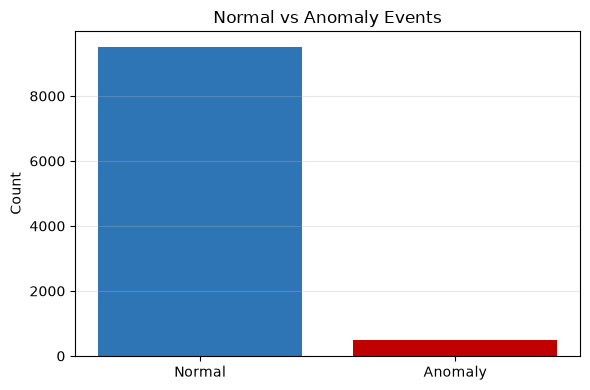

Normal events:  9514 (95.1%)
Anomaly events: 486 (4.9%)


In [4]:

plt.figure(figsize=(6, 4))
counts = df['is_anomaly'].value_counts()
plt.bar(['Normal', 'Anomaly'], counts.values, color=['#2E75B6', '#C00000'])
plt.title('Normal vs Anomaly Events')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Normal events:  {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Anomaly events: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")

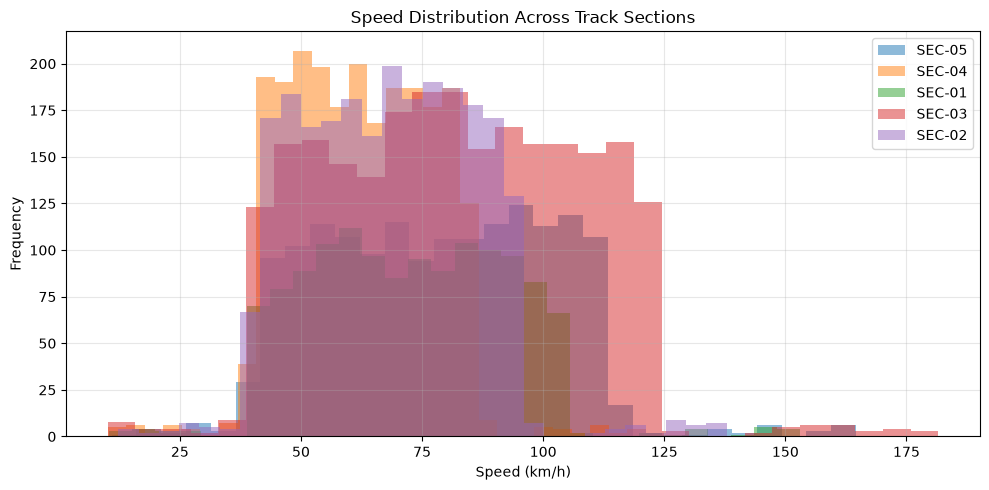

In [5]:
# Chart 2 - Speed distribution per section
plt.figure(figsize=(10, 5))
for section in df['section_id'].unique():
    section_data = df[df['section_id'] == section]['speed_kmh']
    plt.hist(section_data, bins=30, alpha=0.5, label=section)

plt.title('Speed Distribution Across Track Sections')
plt.xlabel('Speed (km/h)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

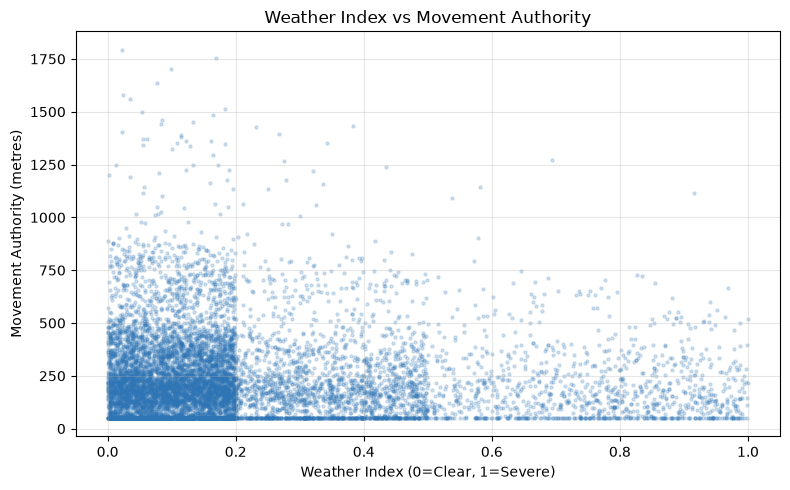

In [6]:
# Chart 3 - Does bad weather reduce Movement Authority?
plt.figure(figsize=(8, 5))
plt.scatter(df['weather_index'], df['movement_authority_m'], 
            alpha=0.2, color='#2E75B6', s=5)
plt.title('Weather Index vs Movement Authority')
plt.xlabel('Weather Index (0=Clear, 1=Severe)')
plt.ylabel('Movement Authority (metres)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


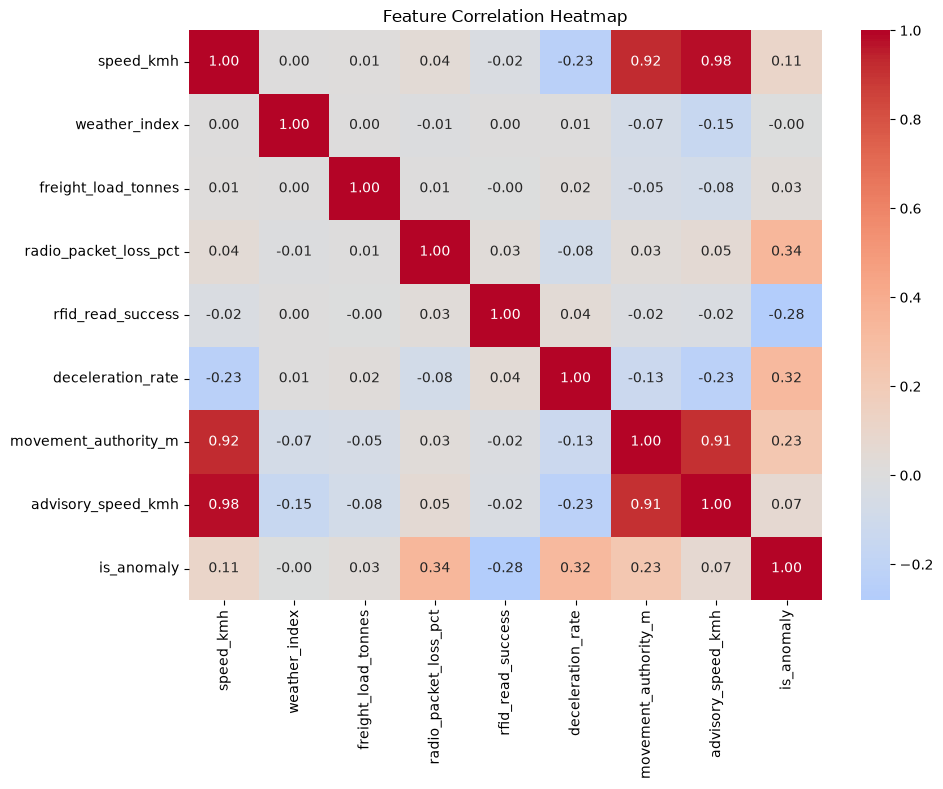

In [7]:
# Chart 4 - Which features are related to each other?
plt.figure(figsize=(10, 8))
numeric_cols = ['speed_kmh', 'weather_index', 'freight_load_tonnes',
                'radio_packet_loss_pct', 'rfid_read_success',
                'deceleration_rate', 'movement_authority_m',
                'advisory_speed_kmh', 'is_anomaly']

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

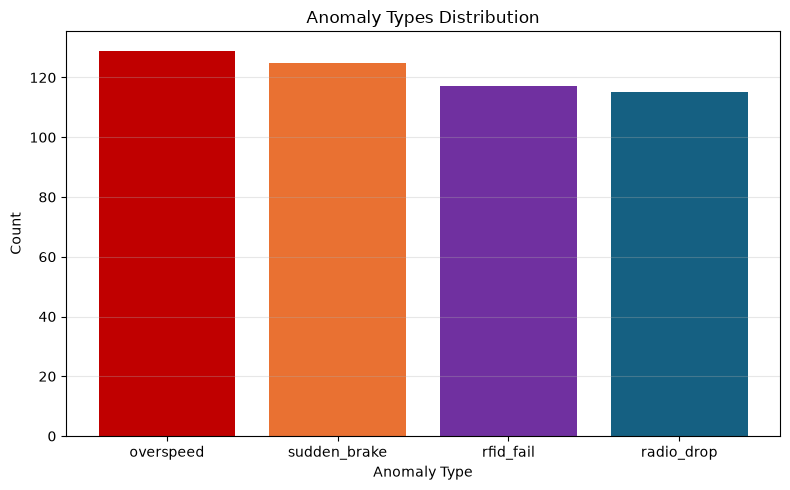


Anomaly breakdown:
  overspeed: 129 events (26.5%)
  sudden_brake: 125 events (25.7%)
  rfid_fail: 117 events (24.1%)
  radio_drop: 115 events (23.7%)


In [8]:
# Chart 5 - What types of anomalies exist?
plt.figure(figsize=(8, 5))
anomaly_df = df[df['is_anomaly'] == 1]
counts = anomaly_df['anomaly_type'].value_counts()
plt.bar(counts.index, counts.values, color=['#C00000', '#E97132', '#7030A0', '#156082'])
plt.title('Anomaly Types Distribution')
plt.xlabel('Anomaly Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAnomaly breakdown:")
for atype, count in counts.items():
    print(f"  {atype}: {count} events ({count/len(anomaly_df)*100:.1f}%)")